# Skin Disease Model - Fitzpatrick 17k

## Setting up Dataset

In [ ]:
import os
import requests
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

In [ ]:
!git clone https://github.com/mattgroh/fitzpatrick17k.git

%cd fitzpatrick17k
!ls

Cloning into 'fitzpatrick17k'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 85 (delta 11), reused 5 (delta 5), pack-reused 66 (from 1)
Receiving objects: 100% (85/85), 4.46 MiB | 13.60 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/fitzpatrick17k
annotation_evaluation  image_deduplication.ipynb       README.md
fitzpatrick17k.csv     ita_fitzpatrick_analysis.ipynb  train.py


In [ ]:
df = pd.read_csv("fitzpatrick17k.csv")

print(df.shape)
df.head()

(16577, 9)


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [ ]:
df = df.dropna(subset=["url", "label"]).reset_index(drop=True)

top_classes = df["label"].value_counts().head(5).index
df = df[df["label"].isin(top_classes)].reset_index(drop=True)

print(df["label"].value_counts())
print("Total rows:", len(df))

label
psoriasis                      653
squamous cell carcinoma        581
lichen planus                  491
basal cell carcinoma           468
allergic contact dermatitis    430
Name: count, dtype: int64
Total rows: 2623


In [ ]:
os.makedirs("images", exist_ok=True)

def download_one(row):
    idx = row.name
    url = row["url"]
    path = f"images/{idx}.jpg"

    if os.path.exists(path) and os.path.getsize(path) > 1000:
        return path

    try:
        response = requests.get(
            url,
            timeout=8,
            headers={"User-Agent": "Mozilla/5.0"},
            allow_redirects=True
        )

        if response.status_code == 200 and len(response.content) > 1000:
            with open(path, "wb") as f:
                f.write(response.content)
            return path

    except:
        return None

    return None

In [ ]:
rows = [row for _, row in df.iterrows()]
image_paths = [None] * len(rows)

with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(download_one, row): i for i, row in enumerate(rows)}

    for future in tqdm(as_completed(futures), total=len(futures)):
        i = futures[future]
        image_paths[i] = future.result()

df["image_path"] = image_paths
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Downloaded usable images:", len(df))
df.head()

100%|██████████| 2623/2623 [14:07<00:00,  3.10it/s]


Downloaded usable images: 846


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,image_path
0,1f2489a044a3e3de6bb33af5359e267b,5,5,squamous cell carcinoma,malignant epidermal,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=3031,httpwwwatlasdermatologicocombrimgimageId3031.jpg,images/1777.jpg
1,5f7dbb59f5c65abfe5ab9258158efa39,4,4,allergic contact dermatitis,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=1148,httpwwwatlasdermatologicocombrimgimageId1148.jpg,images/1778.jpg
2,96c0a686c6d2b974497d4c080d454df5,2,2,squamous cell carcinoma,malignant epidermal,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=6822,httpwwwatlasdermatologicocombrimgimageId6822.jpg,images/1779.jpg
3,8aa5fd77a9d10d03e1f10af68f061394,5,5,lichen planus,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=3928,httpwwwatlasdermatologicocombrimgimageId3928.jpg,images/1780.jpg
4,6eab97097e17ebb49078b6f45c9f185a,1,1,basal cell carcinoma,malignant epidermal,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=650,httpwwwatlasdermatologicocombrimgimageId650.jpg,images/1781.jpg


## Data Pre-Processing

In [ ]:
valid_rows = []

for i, row in df.iterrows():
    try:
        img = Image.open(row["image_path"])
        img.verify()

        if os.path.getsize(row["image_path"]) > 1000:
            valid_rows.append(i)

    except:
        pass

df = df.loc[valid_rows].reset_index(drop=True)

print("Clean images:", len(df))
print(df["label"].value_counts())

Clean images: 846
label
basal cell carcinoma           257
lichen planus                  230
squamous cell carcinoma        212
psoriasis                      104
allergic contact dermatitis     43
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

num_classes = len(label_encoder.classes_)

print("Classes:")
print(label_encoder.classes_)
print("Number of classes:", num_classes)

Classes:
['allergic contact dermatitis' 'basal cell carcinoma' 'lichen planus'
 'psoriasis' 'squamous cell carcinoma']
Number of classes: 5


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 676
Validation: 85
Test: 85


In [ ]:
print("Train distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True))

Train distribution:
label
basal cell carcinoma           0.303254
lichen planus                  0.272189
squamous cell carcinoma        0.251479
psoriasis                      0.122781
allergic contact dermatitis    0.050296
Name: proportion, dtype: float64

Validation distribution:
label
basal cell carcinoma           0.305882
lichen planus                  0.270588
squamous cell carcinoma        0.247059
psoriasis                      0.129412
allergic contact dermatitis    0.047059
Name: proportion, dtype: float64

Test distribution:
label
basal cell carcinoma           0.305882
lichen planus                  0.270588
squamous cell carcinoma        0.247059
psoriasis                      0.117647
allergic contact dermatitis    0.058824
Name: proportion, dtype: float64


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)

    # MobileNetV2 expects pixels scaled to [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [ ]:
def make_dataset(dataframe, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

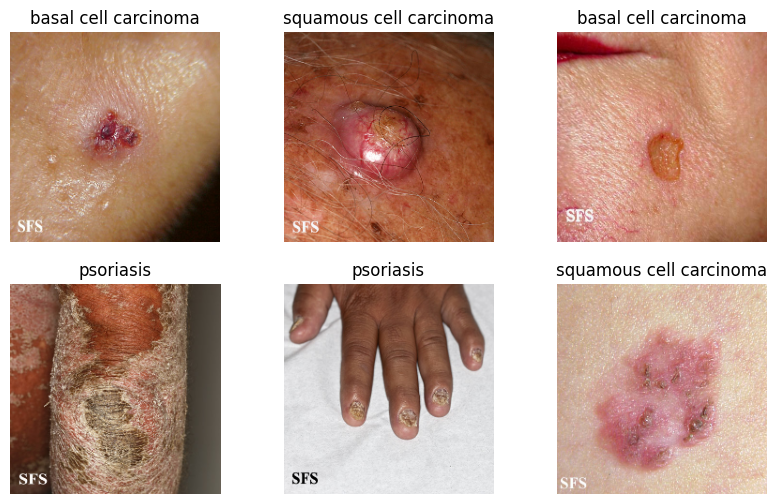

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 6))

    for i in range(6):
        plt.subplot(2, 3, i + 1)

        img = images[i].numpy()
        img = (img + 1) / 2  # undo MobileNet preprocessing for display

        plt.imshow(img)
        plt.title(label_encoder.inverse_transform([labels[i].numpy()])[0])
        plt.axis("off")

    plt.show()

## Model Building

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.3669 - loss: 1.6284 - val_accuracy: 0.4353 - val_loss: 1.3835
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5089 - loss: 1.2430 - val_accuracy: 0.5529 - val_loss: 1.1762
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.5814 - loss: 1.0280 - val_accuracy: 0.5882 - val_loss: 1.1038
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6080 - loss: 0.9606 - val_accuracy: 0.5647 - val_loss: 1.0403
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.6864 - loss: 0.8548 - val_accuracy: 0.6235 - val_loss: 1.0204
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6775 - loss: 0.8002 - val_accuracy: 0.6471 - val_loss: 0.9630
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7012 - loss: 0.7816 - val_accuracy: 0.6471 - val_loss: 1.0062
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7530 - loss: 0.6991 - val_accuracy: 0.6353 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7294 - loss: 0.8126
Test accuracy: 0.729411780834198
Test loss: 0.8126049041748047


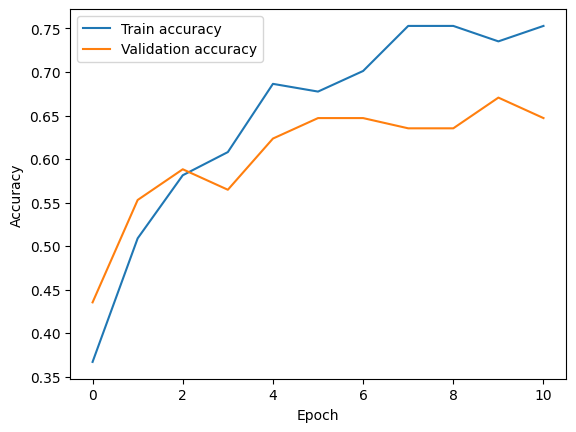

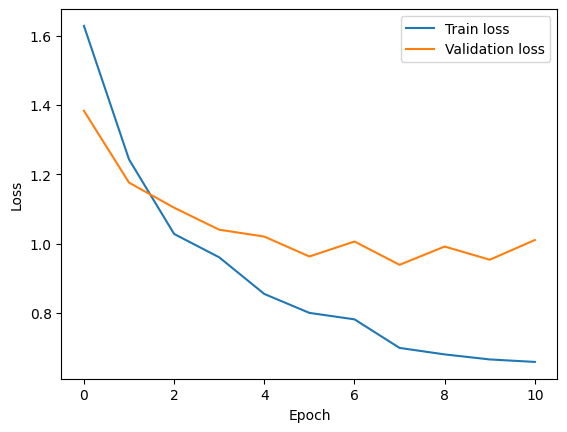

In [ ]:
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
                             precision    recall  f1-score   support

allergic contact dermatitis       0.50      0.60      0.55         5
       basal cell carcinoma       0.79      0.73      0.76        26
              lichen planus       0.76      0.70      0.73        23
                  psoriasis       0.73      0.80      0.76        10
    squamous cell carcinoma       0.70      0.76      0.73        21

                   accuracy                           0.73        85
                  macro avg       0.70      0.72      0.70        85
               weighted avg       0.74      0.73      0.73        85



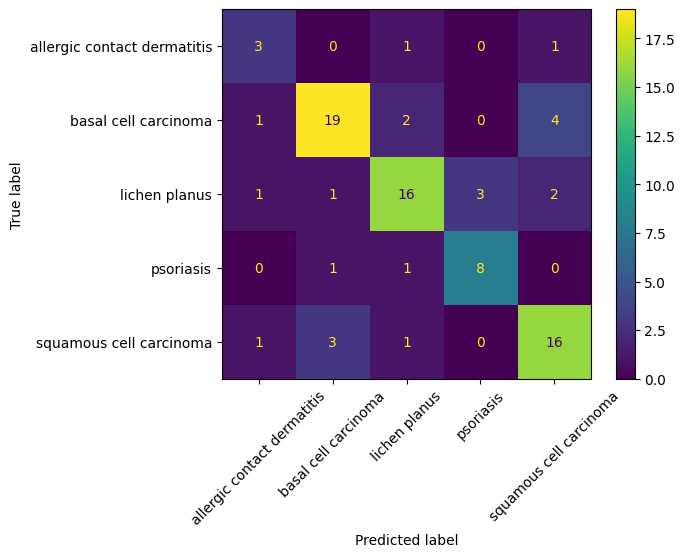

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
model.save("skin_disease_mobilenetv2.keras")

np.save("label_classes.npy", label_encoder.classes_)

In [ ]:
def predict_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = tf.expand_dims(image, axis=0)

    prediction = model.predict(image)
    predicted_id = np.argmax(prediction)
    predicted_label = label_encoder.inverse_transform([predicted_id])[0]

    return predicted_label

In [ ]:
sample_path = test_df.iloc[0]["image_path"]

print("True label:", test_df.iloc[0]["label"])
print("Predicted:", predict_image(sample_path))

True label: basal cell carcinoma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Predicted: squamous cell carcinoma
